In [306]:
import pandas as pd

df = pd.read_csv("./Position_Salaries.csv")
df.head()

,Position,Level,Salary
0,Intern,0.50,30000
1,Trainee,0.75,35000
2,Business Analyst,1.00,45000
3,Junior Consultant,2.00,50000
4,Consultant,2.50,55000


In [307]:
X = df.loc[:, ["Level"]]
y = df["Salary"]

In [308]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
X_transformed = scaler.fit_transform(X)
X_transformed = pd.DataFrame(X, columns=["Level"])
X_transformed.head()

,Level
0,0.50
1,0.75
2,1.00
3,2.00
4,2.50


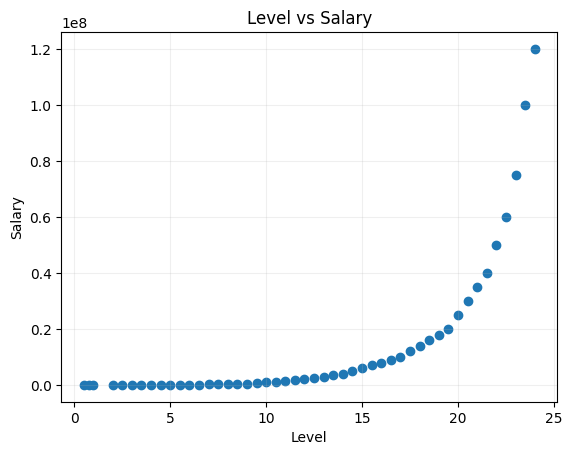

In [309]:
import matplotlib.pyplot as plt

plt.scatter(X_transformed, y)
plt.xlabel("Level")
plt.ylabel("Salary")
plt.grid(True, alpha=0.2)
plt.title("Level vs Salary")
plt.show()

In [310]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_transformed, y, random_state=1997, test_size=0.2
)

In [328]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
pd.DataFrame(X_train).head()

,0,1,2,3,4,5,6
35,1.0,18.0,324.00,5832.000,104976.0000,1.889568e+06,3.401222e+07
11,1.0,6.0,36.00,216.000,1296.0000,7.776000e+03,4.665600e+04
8,1.0,4.5,20.25,91.125,410.0625,1.845281e+03,8.303766e+03
24,1.0,12.5,156.25,1953.125,24414.0625,3.051758e+05,3.814697e+06
28,1.0,14.5,210.25,3048.625,44205.0625,6.409734e+05,9.294114e+06


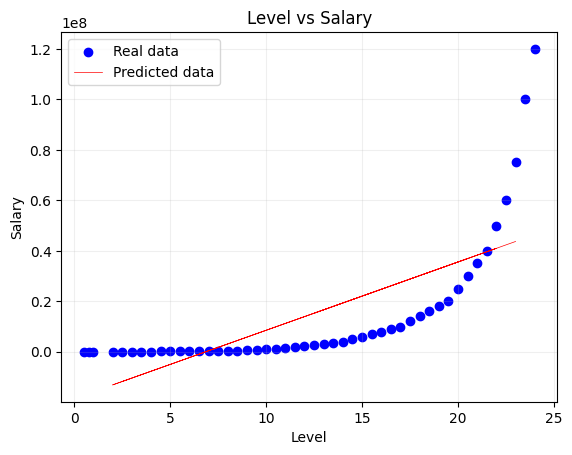

In [312]:
import matplotlib.pyplot as plt

plt.scatter(X_transformed, y, color="blue", label="Real data")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.grid(True, alpha=0.2)
plt.title("Level vs Salary")
plt.plot(
    X_test, y_pred, color="red", linestyle="-", label="Predicted data", linewidth=0.5
)
plt.legend()
plt.show()

In [313]:
residuals = y_test - y_pred
residuals

4     1.185248e+07
43    9.019457e+06
32   -1.709443e+07
24   -1.266817e+07
31   -1.674115e+07
40   -6.920695e+06
3     1.320077e+07
22   -1.076160e+07
27   -1.532802e+07
45    3.131289e+07
Name: Salary, dtype: float64

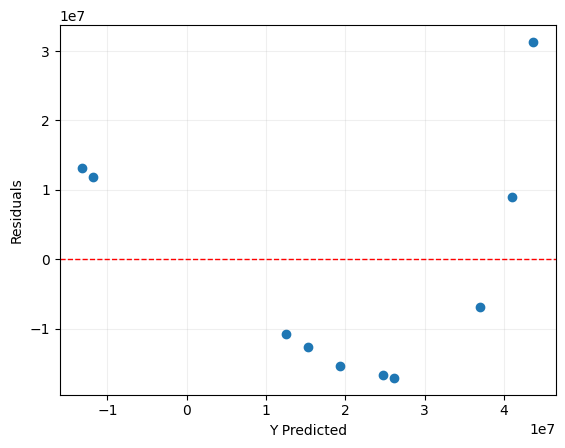

In [314]:
import matplotlib.pyplot as plt

plt.scatter(x=y_pred, y=residuals)
plt.axhline(0, linestyle="--", color="red", linewidth=1)
plt.grid(True, alpha=0.2)
plt.xlabel("Y Predicted")
plt.ylabel("Residuals")
plt.show()

In [344]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split


poly = PolynomialFeatures(3)
X_poly = poly.fit_transform(X_transformed)
X_poly = pd.DataFrame(X_poly)
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, random_state=17, test_size=0.2
)

In [345]:
from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept=False)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
pd.DataFrame(y_pred).head()

,0
0,8.719144e+07
1,4.048765e+07
2,8.962810e+05
3,2.230065e+06
4,-1.362427e+06


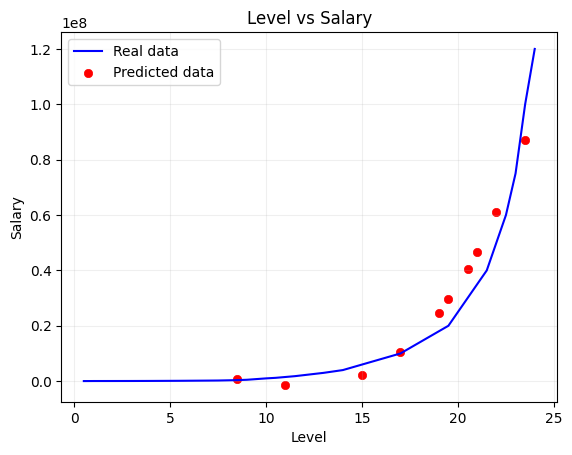

In [346]:
import matplotlib.pyplot as plt

plt.plot(X, y, color="blue", label="Real data")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.grid(True, alpha=0.2)
plt.title("Level vs Salary")
plt.scatter(
    X_test.loc[:, 1],
    y_pred,
    color="red",
    linestyle="-",
    label="Predicted data",
    linewidth=0.5,
)
plt.legend()

In [347]:
residuals = y_test - y_pred
residuals

46    1.280856e+07
40   -1.048765e+07
16   -5.212810e+05
29    3.769935e+06
21    2.862427e+06
38   -9.513169e+06
41   -1.177984e+07
37   -6.785811e+06
43   -1.108675e+07
33   -4.165452e+05
Name: Salary, dtype: float64

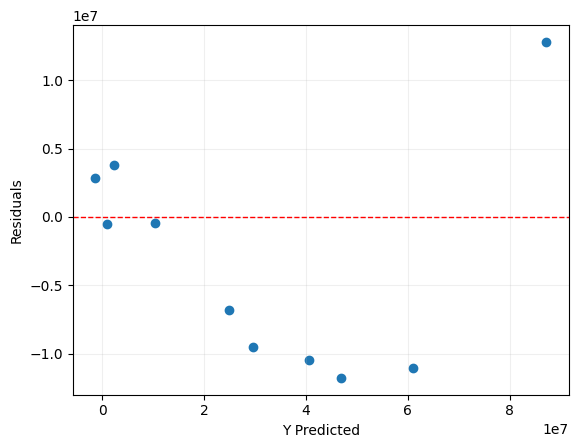

In [348]:
import matplotlib.pyplot as plt

plt.scatter(x=y_pred, y=residuals)
plt.axhline(0, linestyle="--", color="red", linewidth=1)
plt.grid(True, alpha=0.2)
plt.xlabel("Y Predicted")
plt.ylabel("Residuals")
plt.show()

In [349]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"MAE (degree=7): {mae}")
print(f"MSE (degree=7): {mse}")

MAE (degree=7): 7003196.591175946
MSE (degree=7): 69512937207322.85


In [1]:
import statsmodels.api as sm

reg_OLS = sm.OLS(y, X_poly).fit()
reg_OLS.summary()

NameError: name 'y' is not defined